#### 1) importing Necessary Libraries:

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [2]:
df = pd.read_csv('data_banknote_authentication.csv')

In [4]:
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [5]:
df.shape

(1372, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [7]:
df.describe()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


- All featires are Numeric and Continuous.
- There are no missing values in dataset.

#### 3) Data Transformtaion:

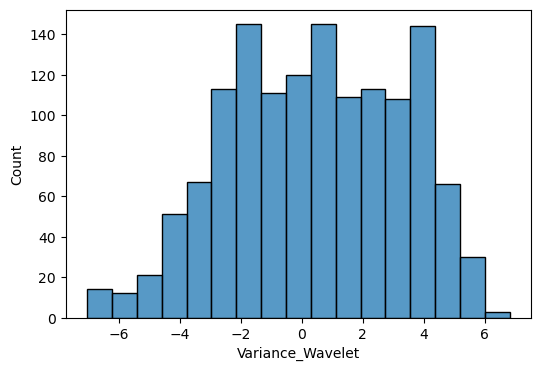

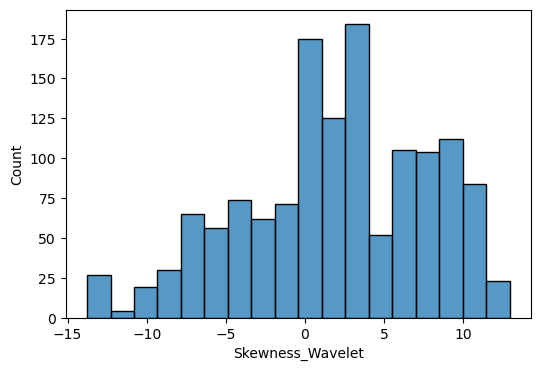

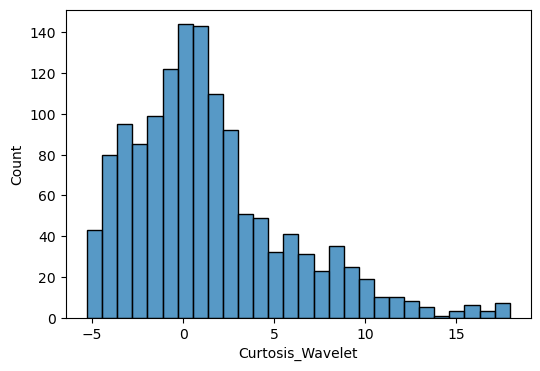

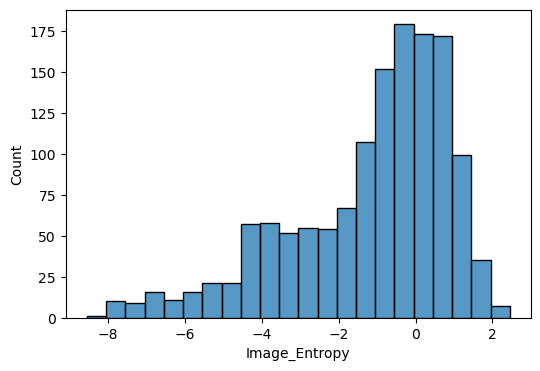

In [11]:
for col in list(df.drop('Class', axis= 1).columns):
    plt.figure(figsize= (6,4))
    sns.histplot(data= df, x= col)
    plt.show()

- 'Curtosis_Wavelet', 'Image_Entropy' features need transformations to make their distribution Normal.

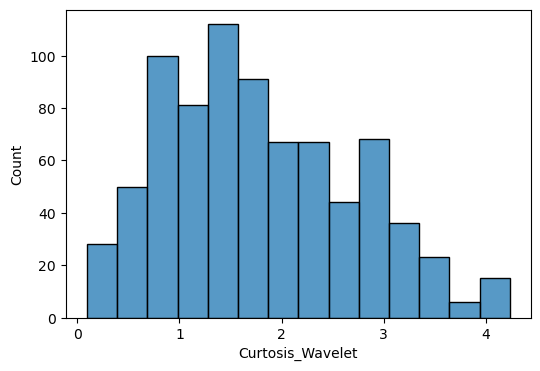

In [34]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Curtosis_Wavelet'].apply(np.sqrt))
plt.show()

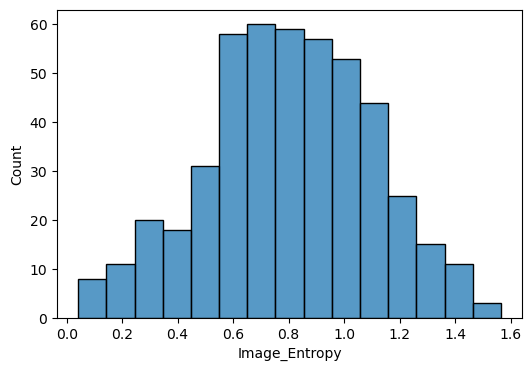

In [35]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['Image_Entropy'].apply(np.sqrt))
plt.show()

- SQRT Transformation is needed for 'Curtosis_Wavelet' and 'Image_Entropy' features.

#### 4) Final Column Transformer:

In [39]:
preprocessor = ColumnTransformer([
    ('SQRT', FunctionTransformer(np.sqrt), ['Curtosis_Wavelet', 'Image_Entropy']),
    ('Scaler', StandardScaler(), [0,1,2,3])
])

#### 5) Train Test Split:

In [40]:
X = df.drop('Class', axis= 1) #Features
y = df['Class'] #Target

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [42]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1097, 4)
(275, 4)
(1097,)
(275,)


#### 6) Random Forest Classifier with Default Parameters:

In [43]:
model_df = Pipeline([
    ('Preprocessing', preprocessor),
    ('Model', RandomForestClassifier())
])

In [44]:
model_df.fit(X_train, y_train) # Model Fitting

C:\Users\shail\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)


,steps,"[('Preprocessing', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('SQRT', ...), ('Scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
y_pred = model_df.predict(X_test) # Predictions Using Model

C:\Users\shail\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)


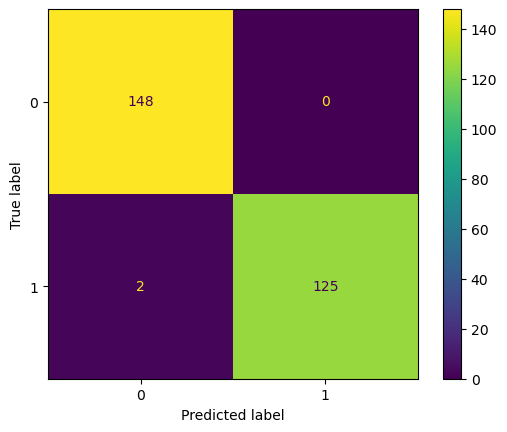

In [46]:
# Confusion Matrix:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels= model_df.classes_)
disp.plot()
plt.show()

In [48]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       148
           1       1.00      0.98      0.99       127

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



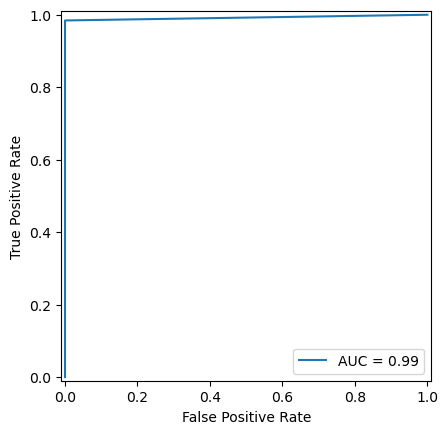

In [49]:
# ROC-AUC Curve:

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
disp = RocCurveDisplay(fpr= fpr, tpr= tpr, roc_auc= roc_auc)
disp.plot()
plt.show()

#### 7) Grid Search on Random Forest Classifier:

In [53]:
model = RandomForestClassifier()

param_dict = {'n_estimators': [1,10,50,100,200],
             'criterion': ['gini', 'entropy'],
             'max_features': [2, 3, 4],
             'bootstrap': [True, False],
             'oob_score': [True, False]}

grid_model = GridSearchCV(estimator= model, 
                         param_grid= param_dict,
                         cv= 10)

In [54]:
grid_pipeline = Pipeline([
    ('Preprocessing', preprocessor),
    ('Grid', grid_model)
])

In [55]:
grid_pipeline.fit(X_train, y_train) # Fitting Grid Model

,steps,"[('Preprocessing', ...), ('Grid', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('SQRT', ...), ('Scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
# Best Estimator and Prameters in Grid Model:

print(grid_pipeline.named_steps['Grid'].best_score_)
print(grid_pipeline.named_steps['Grid'].best_estimator_)
print(grid_pipeline.named_steps['Grid'].best_params_)

0.993628023352794
RandomForestClassifier(criterion='entropy', max_features=2, n_estimators=10)
{'bootstrap': True, 'criterion': 'entropy', 'max_features': 2, 'n_estimators': 10, 'oob_score': False}


In [58]:
y_pred = grid_pipeline.predict(X_test) # Predictions Using Best Estimator from Grid Model

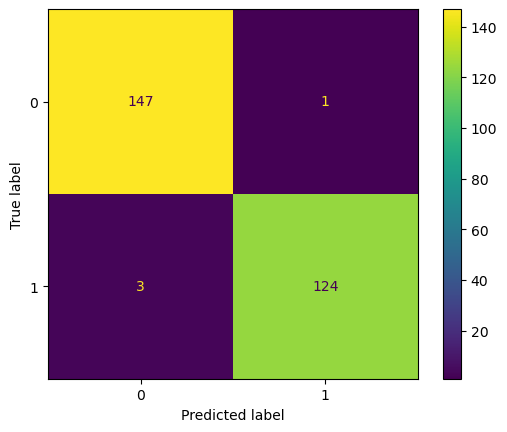

In [59]:
# Confusion Matrix:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels= grid_pipeline.classes_)
disp.plot()
plt.show()

In [61]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       148
           1       0.99      0.98      0.98       127

    accuracy                           0.99       275
   macro avg       0.99      0.98      0.99       275
weighted avg       0.99      0.99      0.99       275



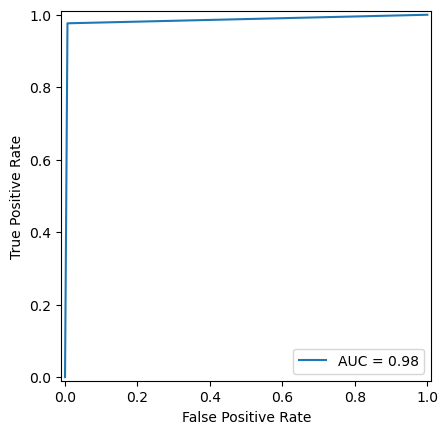

In [62]:
# ROC-AUC Curve:

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
disp = RocCurveDisplay(fpr= fpr, tpr= tpr, roc_auc= roc_auc)
disp.plot()
plt.show()

In [65]:
# CV Wise Score in Grid Model:

pd.DataFrame(data= grid_model.cv_results_)[['params', 'mean_test_score', 'rank_test_score']]

,params,mean_test_score,rank_test_score
0,"{'bootstrap': True, 'criterion': 'gini', 'max_...",0.971751,83
1,"{'bootstrap': True, 'criterion': 'gini', 'max_...",0.968107,86
2,"{'bootstrap': True, 'criterion': 'gini', 'max_...",0.989074,51
3,"{'bootstrap': True, 'criterion': 'gini', 'max_...",0.990884,20
4,"{'bootstrap': True, 'criterion': 'gini', 'max_...",0.990901,4
...,...,...,...
115,"{'bootstrap': False, 'criterion': 'entropy', '...",0.989975,47
116,"{'bootstrap': False, 'criterion': 'entropy', '...",NaN,91
117,"{'bootstrap': False, 'criterion': 'entropy', '...",0.989983,23
118,"{'bootstrap': False, 'criterion': 'entropy', '...",NaN,91


#### 8) Error vs. Number of Estimators:

In [67]:
# Preprocessing Training and Test Data:

X_train_sc = preprocessor.fit_transform(X_train)
X_test_sc = preprocessor.transform(X_test)

In [69]:
errors = []

for num in range(1,100):

    tree = RandomForestClassifier(n_estimators= num) # Model Instance
    tree.fit(X_train_sc, y_train) # Model Fitting
    pred = tree.predict(X_test_sc) # Preictions Using Model
    errors.append(1 - accuracy_score(y_test, pred)) # Appending Error Rate (1- Accuracy) to Errors List.

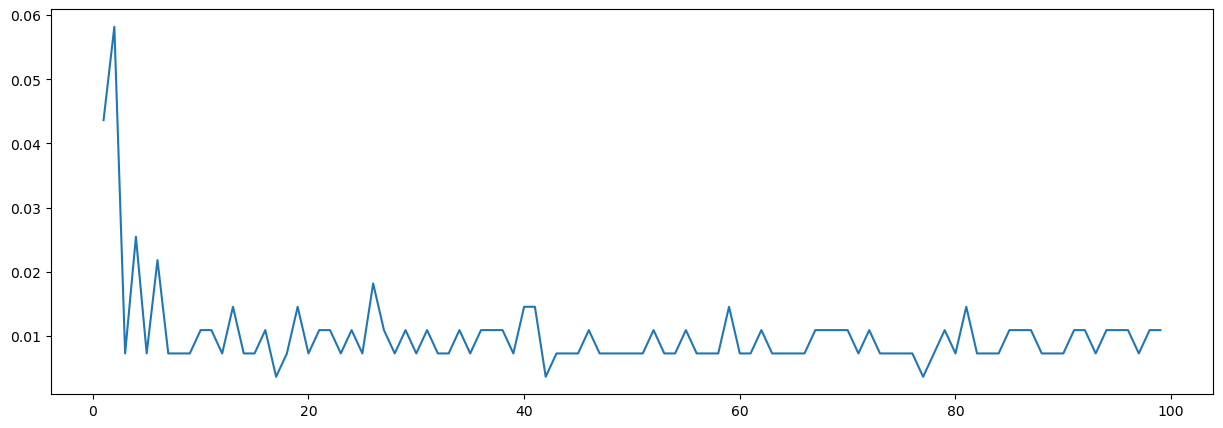

In [71]:
# Plotting Errors:

plt.figure(figsize=(15,5))
sns.lineplot(x= range(1,100), y= errors)
plt.show()

- As seen from the Graph, we can get the same accuracy as 50 trees with 3 trees too.